In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from dotenv import load_dotenv
import os
from wordcloud import WordCloud
load_dotenv()
import re
print("Done")

Done


In [64]:
df = pd.read_csv(os.getenv("RAW-DATA-PATH"))

In [65]:
df.sample(2)

,review,sentiment
27907,The first Home Alone was a decent enough film....,negative
461,Don't listen to most of these people. ill give...,positive


In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [67]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [68]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

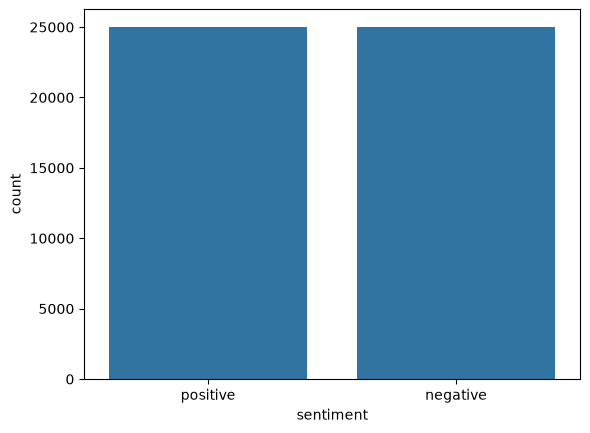

In [69]:
sns.countplot(data=df, x="sentiment")
plt.show()

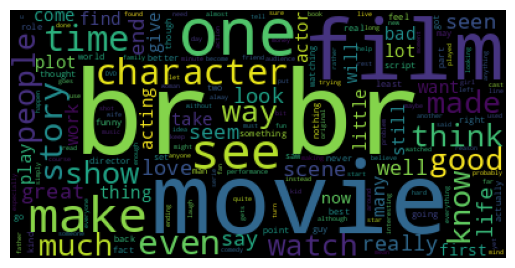

In [70]:
text = " ".join(df["review"].astype(str))

plt.imshow(WordCloud().generate(text))
plt.axis("off")
plt.show()

## As the dataset is balanced.Let's got to Data Cleaning Part

In [71]:
mapping = {'positive':1,'negative':0}
y = df['sentiment']

In [72]:
y.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [73]:
df['sentiment']=y.map(mapping)

In [74]:
df.sample(4)

,review,sentiment
47778,Horror spoofs are not just a thing of the 21st...,0
32706,"For me an unsatisfactory, unconvincing heist m...",0
48556,I agree with most if not all of the previous c...,0
33499,We rented the movie and it maybe the worst mov...,0


In [75]:
reviews = df['review']

In [76]:
reviews

0        One of the other reviewers has mentioned that ...
1        A wonderful little production. <br /><br />The...
2        I thought this was a wonderful way to spend ti...
3        Basically there's a family where a little boy ...
4        Petter Mattei's "Love in the Time of Money" is...
                               ...                        
49995    I thought this movie did a down right good job...
49996    Bad plot, bad dialogue, bad acting, idiotic di...
49997    I am a Catholic taught in parochial elementary...
49998    I'm going to have to disagree with the previou...
49999    No one expects the Star Trek movies to be high...
Name: review, Length: 50000, dtype: str

In [77]:
def clean_text(sentence):
    if not isinstance(sentence,str):
        return ""
    text = sentence.lower()
    text = re.sub(r'<[^>]*>','',text)
    text = re.sub(r'https?://\S+|www\.\S+','',text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()
    

In [78]:
reviews = reviews.apply(clean_text)

In [79]:
reviews

0        one of the other reviewers has mentioned that ...
1        a wonderful little production the filming tech...
2        i thought this was a wonderful way to spend ti...
3        basically theres a family where a little boy j...
4        petter matteis love in the time of money is a ...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    i am a catholic taught in parochial elementary...
49998    im going to have to disagree with the previous...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: str

In [80]:
vocabulary = set(" ".join(reviews.astype(str)).split())

In [81]:
vocabulary

{'middlethis',
 'sosad',
 'attentionscarlett',
 'ivanic',
 'chen',
 'berghuis',
 'succeds',
 'overnightbut',
 'kangaroos',
 'devolvement',
 'themselveswhich',
 'citythe',
 'lindberghas',
 'filmdvd',
 'affirmation',
 'thisthe',
 'redbone',
 'scouse',
 'navigate',
 'regiments',
 'axn',
 'fourththere',
 'doordont',
 'nativesthe',
 'negative',
 'reportary',
 'geilgud',
 'robotlooks',
 'glorious',
 'dryeyed',
 'bejarano',
 'nancherrow',
 'navajomost',
 'himhimand',
 'secrets',
 'ladiesinwaiting',
 'livesbogart',
 'whoresand',
 'soooooo',
 'formatthe',
 'grease',
 'infinnerty',
 'vitally',
 'doomed',
 'creationism',
 'kiddingbustin',
 'schooler',
 'frontpage',
 'nuttery',
 'afreshshame',
 'middleits',
 'wellever',
 'continued',
 'timenot',
 'muchachas',
 'thamesbarrier',
 'virtuoso',
 'showing',
 'sitcomlike',
 'gagoola',
 'fishback',
 'presecond',
 'hearta',
 'sha',
 'halfpoor',
 'zombievirussubplot',
 'heterarchical',
 'sloganeering',
 'condemnationabout',
 'lately',
 'ronet',
 'eriksen',


In [82]:
df['review'] = reviews

In [85]:
folder_path = os.getenv("PROCESSED_DATA_PATH")

In [86]:
if folder_path:
    output_file_path = os.path.join(folder_path, 'cleaned_reviews.csv')
    os.makedirs(folder_path, exist_ok=True)
    df.to_csv(output_file_path, index=False)
    print(f"✅ Success! File saved to: {output_file_path}")
else:
    print("❌ Error: The specified environment variable was not found.")

✅ Success! File saved to: ../data/processed/cleaned_reviews.csv
